## You only have to edit cell 3 with the correct path to your data file.

In [117]:
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax, vmap, jit
import matplotlib.pyplot as plt
import pymaster as nmt
from tqdm import tqdm
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy import units as u
from pathlib import Path

from brute_cov import (
    build_binning_matrix, pad_binning_matrix,
    compute_cos_theta, mcm_binning,
    compute_legendre,
    sample_covariance_healpy,
)
from utils2 import *

In [118]:
compute_legendre_jitted = jax.jit(compute_legendre, static_argnames='lmax')
@jax.jit
def corr(s, P):
    return jnp.einsum('l, lij->ij', s, P)


In [ ]:
data = np.load("mock_masked_fixed.npz")
#data = np.load("mock_catalog.npz")

print(data.files)

['ra', 'dec', 'ell', 'cell', 'nside_sim', 'noise_mean', 'noise_var', 'position_source', 'position_mask_mode', 'DM', 'n_completed', 'seeds', 'pcl_ell_eff', 'pcl_edges', 'pcl_dm', 'pcl_dm_gaussian', 'pcl_dm_lognormal', 'pcl_theory']


In [120]:



RA = data['ra']
DEC = data['dec']
DM = data['DM']
# DM_gaussian = data['series']['DM_gaussian']
# DM_lognormal = data['series']['DM_lognormal']

transformation = SkyCoord(ra=RA*u.degree, dec=DEC*u.degree, frame='icrs').galactic
gl, gb = np.array(transformation.l), np.array(transformation.b)
pos = np.array([gl, gb])

In [121]:
edges = data['pcl_edges']
lmin = np.min(edges)
lmax_nside = np.max(edges)
lmax = lmax_nside
b = nmt.NmtBin.from_edges(edges[:-1], edges[1:])
w = np.ones(gl.size)

In [122]:
f_mask = nmt.NmtFieldCatalog(positions = [gl, gb], weights = w, field= None,
                         lmax = b.lmax, spin = 0, lonlat=True )    


wasp = nmt.NmtWorkspace.from_fields(f_mask, f_mask, b)
mcm = jnp.asarray(wasp.get_coupling_matrix())
mcm_inv = np.linalg.inv(mcm)


In [123]:
Binning, ell_eff = build_binning_matrix(edges)
Binning_matrix_padded = pad_binning_matrix(Binning, lmin, lmax)
Binning_matrix_padded = jnp.array(Binning_matrix_padded)
TB = Binning_matrix_padded @ mcm_inv

In [124]:
def sum_matrices(pos, w, TB, lmax, full_ells, Sl_unbinned, noise_variance, chunk_size):

    N = pos.shape[1]
    remainder = N % chunk_size
    if remainder != 0:
        pad_size = chunk_size - remainder
        pos = jnp.concatenate([pos, jnp.zeros((pos.shape[0], pad_size))], axis=1)
        w   = jnp.concatenate([w,   jnp.zeros(pad_size)])
    n_chunks = pos.shape[1] // chunk_size
    dim_cov  = TB.shape[0]
    carry_init = jnp.zeros((dim_cov, dim_cov))

    N_xi = 100 * lmax
    # Uniform in theta (not cos theta) gives dense sampling near theta=0,
    # resolving the rapidly-oscillating Legendre polynomials at large ell.
    # linspace(pi, 0) -> cos goes from -1 to +1 (ascending, required by jnp.interp).
    cos_theta_grid = jnp.cos(jnp.linspace(jnp.pi, 0.0, N_xi))
    P_1d    = compute_legendre_jitted(cos_theta_grid, lmax)
    xi_grid = jnp.einsum('l, lk -> k',
                         (2 * full_ells + 1) * Sl_unbinned, P_1d) / 4.0 / np.pi

    def signal_corr_pair(pos_x, pos_y):
        cos_theta = compute_cos_theta(pos_x[0], pos_x[1], pos_y[0], pos_y[1])
        return jnp.interp(cos_theta.ravel(), cos_theta_grid, xi_grid).reshape(cos_theta.shape)

    def sum_over_i(i, carr_i):
        posi = lax.dynamic_slice(pos, (0, i * chunk_size), (2, chunk_size))
        wi   = lax.dynamic_slice(w,   (i * chunk_size,),  (chunk_size,))

        def sum_over_j(j, carr_j):
            # Exploit f(i,j,a,b) = f(j,i,b,a): only compute j >= i, multiply by 4.
            # For j == i (intra-chunk), use upper triangle to avoid double-counting k<->m.
            def compute_j(_):
                posj = lax.dynamic_slice(pos, (0, j * chunk_size), (2, chunk_size))
                wj   = lax.dynamic_slice(w,   (j * chunk_size,),  (chunk_size,))

                w_ij = wi[:, None] * wj[None, :]
                # For i == j, keep only upper triangle (k < m) since the (j,i,b,a)
                # mirror of the i==j block is itself; lower triangle would double-count.
                w_ij = lax.cond(i == j,
                                lambda x: jnp.triu(x, k=1),
                                lambda x: x, w_ij)

                cos_theta_ij = compute_cos_theta(posi[0], posi[1], posj[0], posj[1])
                P_ij   = compute_legendre_jitted(cos_theta_ij, lmax)
                TBP_ij = mcm_binning(TB, P_ij)

                def sum_over_a(a, carr_a):
                    posa = lax.dynamic_slice(pos, (0, a * chunk_size), (2, chunk_size))
                    wa   = lax.dynamic_slice(w,   (a * chunk_size,),  (chunk_size,))

                    signal_corr_ia = signal_corr_pair(posi, posa)
                    noise_mat      = noise_variance * jnp.eye(chunk_size)
                    full_field_corr_ia = lax.cond(i == a,
                                                  lambda s, n: s + n,
                                                  lambda s, n: s,
                                                  signal_corr_ia, noise_mat)

                    def sum_over_b(b, carr_b):
                        posb = lax.dynamic_slice(pos, (0, b * chunk_size), (2, chunk_size))
                        wb   = lax.dynamic_slice(w,   (b * chunk_size,),  (chunk_size,))

                        w_ab = wa[:, None] * wb[None, :]
                        w_ab = lax.cond(a == b,
                                        lambda x: x - jnp.diag(jnp.diag(x)),
                                        lambda x: x, w_ab)

                        cos_theta_ab   = compute_cos_theta(posa[0], posa[1], posb[0], posb[1])
                        P_ab           = compute_legendre_jitted(cos_theta_ab, lmax)
                        TBP_ab         = mcm_binning(TB, P_ab)

                        signal_corr_jb = signal_corr_pair(posj, posb)
                        full_field_corr_jb = lax.cond(j == b,
                                                       lambda s, n: s + n,
                                                       lambda s, n: s,
                                                       signal_corr_jb, noise_mat)

                        Cov_binned = (4 * jnp.einsum('ij, aij, km, bkm, ik, jm -> ab',
                                                      w_ij, TBP_ij,
                                                      w_ab, TBP_ab,
                                                      full_field_corr_ia,
                                                      full_field_corr_jb) / (4 * np.pi) ** 2)
                        jax.debug.print('The value of the indices is {} {} {} {}', i, j, a, b)

                        return carr_b + Cov_binned

                    return lax.fori_loop(0, n_chunks, sum_over_b, carr_a)

                return lax.fori_loop(0, n_chunks, sum_over_a, carr_j)

            return lax.cond(j >= i, compute_j, lambda _: carr_j, None)

        return lax.fori_loop(0, n_chunks, sum_over_j, carr_i)

    return lax.fori_loop(0, n_chunks, sum_over_i, carry_init)


sum_matrices_jitted = jit(sum_matrices, static_argnames=('lmax', 'chunk_size'))


In [125]:
n_chunks = 2000


f = nmt.NmtFieldCatalog(positions = [gl, gb], weights=w, field = DM[None, :], lmax=b.lmax, lonlat=True, spin = 0)

Sl_coupled = nmt.compute_coupled_cell(f, f) # the coupled, noise subtracted power spectrum  
Nf = f.Nf
Sl = wasp.decouple_cell(Sl_coupled)
Sl_unbinned = b.unbin_cell(Sl)[0]

ells = b.get_effective_ells()



full_ells = jnp.arange(0, edges[-1])



cl_th = data['cell']
cl_th_coupled = wasp.couple_cell(cl_th[None, :edges[-1]])
cl_th_decoupled = wasp.decouple_cell(cl_th_coupled)
cl_th_decoupled_unbinned = b.unbin_cell(cl_th_decoupled)[0]

cov = np.cov(data['pcl_dm'].T)



field_variance = jnp.sum((2*full_ells + 1)*cl_th[:edges[-1]])/4./np.pi
var_f = np.var(DM) + np.mean(DM)**2
noise_variance = var_f - field_variance

In [126]:
# Block jackknife error on the sample covariance from the data realisations.
# With N=10000 and n_blocks=100 each block holds 100 realisations;
# each leave-one-out estimate uses 9900 realisations.
n_blocks = 100
pcl_dm   = data['pcl_dm']          # shape (N_real, nbins)
N_real   = pcl_dm.shape[0]
block_size = N_real // n_blocks

cov_jk = np.zeros((n_blocks, cov.shape[0], cov.shape[1]))
for k in range(n_blocks):
    mask = np.ones(N_real, dtype=bool)
    mask[k * block_size : (k + 1) * block_size] = False
    cov_jk[k] = np.cov(pcl_dm[mask].T)

cov_jk_mean = cov_jk.mean(axis=0)
cov_err = np.sqrt((n_blocks - 1) / n_blocks * np.sum((cov_jk - cov_jk_mean) ** 2, axis=0))

# Error on sigma = sqrt(cov_diag) via error propagation
sigma_data     = np.sqrt(np.diag(cov))
sigma_data_err = np.diag(cov_err) / (2 * sigma_data)

print('Diagonal fractional jackknife error (cov_err / cov):',
      np.diag(cov_err) / np.diag(cov))

Diagonal fractional jackknife error (cov_err / cov): [0.04756803 0.04242223 0.0488575  0.04340738 0.04519306 0.04811759
 0.05021487 0.04585084 0.0467759  0.04694318 0.04565507 0.047932  ]


In [ ]:
cov_gpu_th = sum_matrices_jitted(pos, w, TB, int(edges[-1]), full_ells, cl_th_decoupled_unbinned, noise_variance, n_chunks)

The value of the indices is 0 0 0 0
The value of the indices is 0 0 0 1
The value of the indices is 0 0 0 2
The value of the indices is 0 0 0 3
The value of the indices is 0 0 0 4
The value of the indices is 0 0 0 5
The value of the indices is 0 0 0 6
The value of the indices is 0 0 0 7
The value of the indices is 0 0 0 8
The value of the indices is 0 0 0 9
The value of the indices is 0 0 0 10
The value of the indices is 0 0 0 11
The value of the indices is 0 0 0 12
The value of the indices is 0 0 0 13
The value of the indices is 0 0 0 14
The value of the indices is 0 0 0 15
The value of the indices is 0 0 0 16
The value of the indices is 0 0 0 17
The value of the indices is 0 0 0 18
The value of the indices is 0 0 0 19
The value of the indices is 0 0 0 20
The value of the indices is 0 0 0 21
The value of the indices is 0 0 0 22
The value of the indices is 0 0 0 23
The value of the indices is 0 0 0 24
The value of the indices is 0 0 1 0
The value of the indices is 0 0 1 1
The value of 

## Sample covariance benchmark via HEALPix simulations

Run `sample_covariance_healpy` to get a Monte Carlo estimate of the covariance and compare its diagonal against the analytic result from `sum_matrices_jitted`.

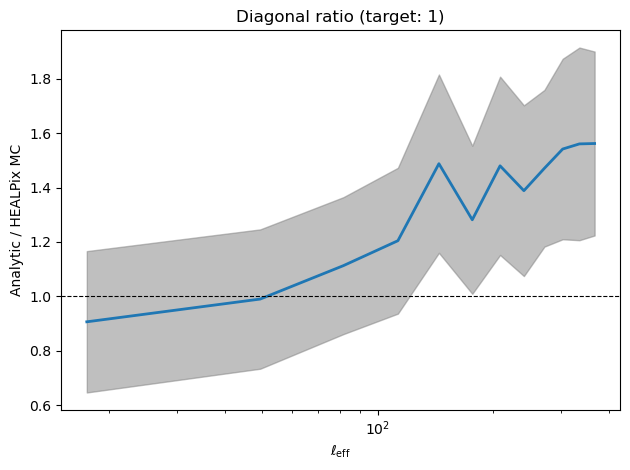

In [ ]:
ell_eff = data['pcl_ell_eff']

fig, axes = plt.subplots()

Cov_sim = cov

# --- Right: ratio analytic / simulation ---
ax = axes
ax.semilogx(ell_eff, np.diag(cov_gpu_th) / np.diag(Cov_sim), lw=2)
ax.fill_between(ell_eff,
                (np.diag(cov_gpu_th) / np.diag(Cov_sim)) * (1 - np.sqrt(np.diag(cov_err) / np.diag(cov))),
                (np.diag(cov_gpu_th) / np.diag(Cov_sim)) * (1 + np.sqrt(np.diag(cov_err) / np.diag(cov))),
                color='gray', alpha=0.5, label='Jackknife error on data covariance')
ax.axhline(1.0, color='k', ls='--', lw=0.8)
ax.set_xlabel(r'$\ell_{\rm eff}$')
ax.set_ylabel('Analytic / HEALPix MC')
ax.set_title('Diagonal ratio (target: 1)')

plt.tight_layout()
plt.show()

np.savez("covariance_forecast.npz", cov=cov_gpu_th, ell_eff=ell_eff, cov_err=cov_err, sigma_data=sigma_data, sigma_data_err=sigma_data_err)
#np.savez("covariance_catalog.npz", cov=cov_gpu_th, ell_eff=ell_eff, cov_err=cov_err, sigma_data=sigma_data, sigma_data_err=sigma_data_err)